In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('./dataset/Predict Hair Fall.csv')
df.head()

,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss
0,133992,Yes,No,No Data,No Data,Magnesium deficiency,Moderate,19,Yes,Yes,No,No,0
1,148393,No,No,Eczema,Antibiotics,Magnesium deficiency,High,43,Yes,Yes,No,No,0
2,155074,No,No,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,Yes,Yes,No,Yes,0
3,118261,Yes,Yes,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,Yes,Yes,No,No,0
4,111915,No,No,Psoriasis,Accutane,Iron deficiency,Moderate,30,No,Yes,Yes,No,1


In [3]:
print(df.isnull().sum())

Id                           0
Genetics                     0
Hormonal Changes             0
Medical Conditions           0
Medications & Treatments     0
Nutritional Deficiencies     0
Stress                       0
Age                          0
Poor Hair Care Habits        0
Environmental Factors        0
Smoking                      0
Weight Loss                  0
Hair Loss                    0
dtype: int64


In [4]:
binary_cols = [
    'Genetics', 
    'Hormonal Changes', 
    'Poor Hair Care Habits ', 
    'Environmental Factors', 
    'Smoking', 
    'Weight Loss '
]

# Define the mapping: 'Yes' to 1, 'No' to 0
mapping = {'Yes': 1, 'No': 0}

for col in binary_cols:
    df[col] = df[col].replace(mapping)

df.head()

/var/folders/lq/jml0g7pd4fq5z4jbc45z9t8h0000gn/T/ipykernel_1192/345871822.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(mapping)


,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss
0,133992,1,0,No Data,No Data,Magnesium deficiency,Moderate,19,1,1,0,0,0
1,148393,0,0,Eczema,Antibiotics,Magnesium deficiency,High,43,1,1,0,0,0
2,155074,0,0,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,1,1,0,1,0
3,118261,1,1,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,1,1,0,0,0
4,111915,0,0,Psoriasis,Accutane,Iron deficiency,Moderate,30,0,1,1,0,1


In [5]:
HIGH_CARDINALITY_COLS = [
    'Medical Conditions', 
    'Medications & Treatments', 
    'Nutritional Deficiencies '
]

# Combine any category that appears in less than 5% of the data into 'RARE'.
RARITY_THRESHOLD = 0.05 
MISSING_VALUE_STR = 'No Data'

def group_rare_categories(df, column, threshold, missing_str):
    """
    Groups categories that are below a certain frequency threshold into a 
    'RARE' group and standardizes missing values.
    """
    # print(f"Processing column: {column}")
    
    df[column] = df[column].replace(missing_str, 'MISSING')
    
    # value_counts = df[column].value_counts(normalize=True)
    # rare_categories = value_counts[value_counts < threshold].index.tolist()
    # print(f"Old unique values for {column}: {df[column].nunique()}")
    # df[column] = df[column].replace(rare_categories, 'RARE')
    # print(f"New unique values for {column}: {df[column].nunique()}")
    # print(df[column].value_counts(normalize=True).round(3))
    # print("-" * 50)
    
    return df

for col in HIGH_CARDINALITY_COLS:
    df = group_rare_categories(df, col, RARITY_THRESHOLD, MISSING_VALUE_STR)

In [6]:
stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress'] = df['Stress'].replace(stress_mapping).astype(int)

/var/folders/lq/jml0g7pd4fq5z4jbc45z9t8h0000gn/T/ipykernel_1192/3319698627.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Stress'] = df['Stress'].replace(stress_mapping).astype(int)


In [7]:
df['Age_Group'], age_bins = pd.qcut(
    df['Age'], 
    q=4, 
    labels=False, 
    duplicates='drop',
    retbins=True
)

lowest_age = df['Age'].min()
highest_age = df['Age'].max()
print(f"The minimum age in the dataset is: {lowest_age}")
print(f"The maximum age in the dataset is: {highest_age}")

# Convert the bins array into readable ranges
bin_ranges = []
for i in range(len(age_bins) - 1):
    # Format the range as [Lower Bound, Upper Bound]
    lower = round(age_bins[i], 1)
    upper = round(age_bins[i+1], 1)
    bin_ranges.append(f"Bin {i}: ({lower} to {upper}]")

print("--- AGE GROUP BINS (QUARTILES) ---")
for range_str in bin_ranges:
    print(range_str)
print("-" * 50)

#Replace the original 'Age' column with the new binned feature
df = df.drop(columns=['Age']) 

The minimum age in the dataset is: 18
The maximum age in the dataset is: 50
--- AGE GROUP BINS (QUARTILES) ---
Bin 0: (18.0 to 26.0]
Bin 1: (26.0 to 34.0]
Bin 2: (34.0 to 42.0]
Bin 3: (42.0 to 50.0]
--------------------------------------------------


In [8]:
df.head()

,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss,Age_Group
0,133992,1,0,MISSING,MISSING,Magnesium deficiency,1,1,1,0,0,0,0
1,148393,0,0,Eczema,Antibiotics,Magnesium deficiency,2,1,1,0,0,0,3
2,155074,0,0,Dermatosis,Antifungal Cream,Protein deficiency,1,1,1,0,1,0,0
3,118261,1,1,Ringworm,Antibiotics,Biotin Deficiency,1,1,1,0,0,0,3
4,111915,0,0,Psoriasis,Accutane,Iron deficiency,1,0,1,1,0,1,1


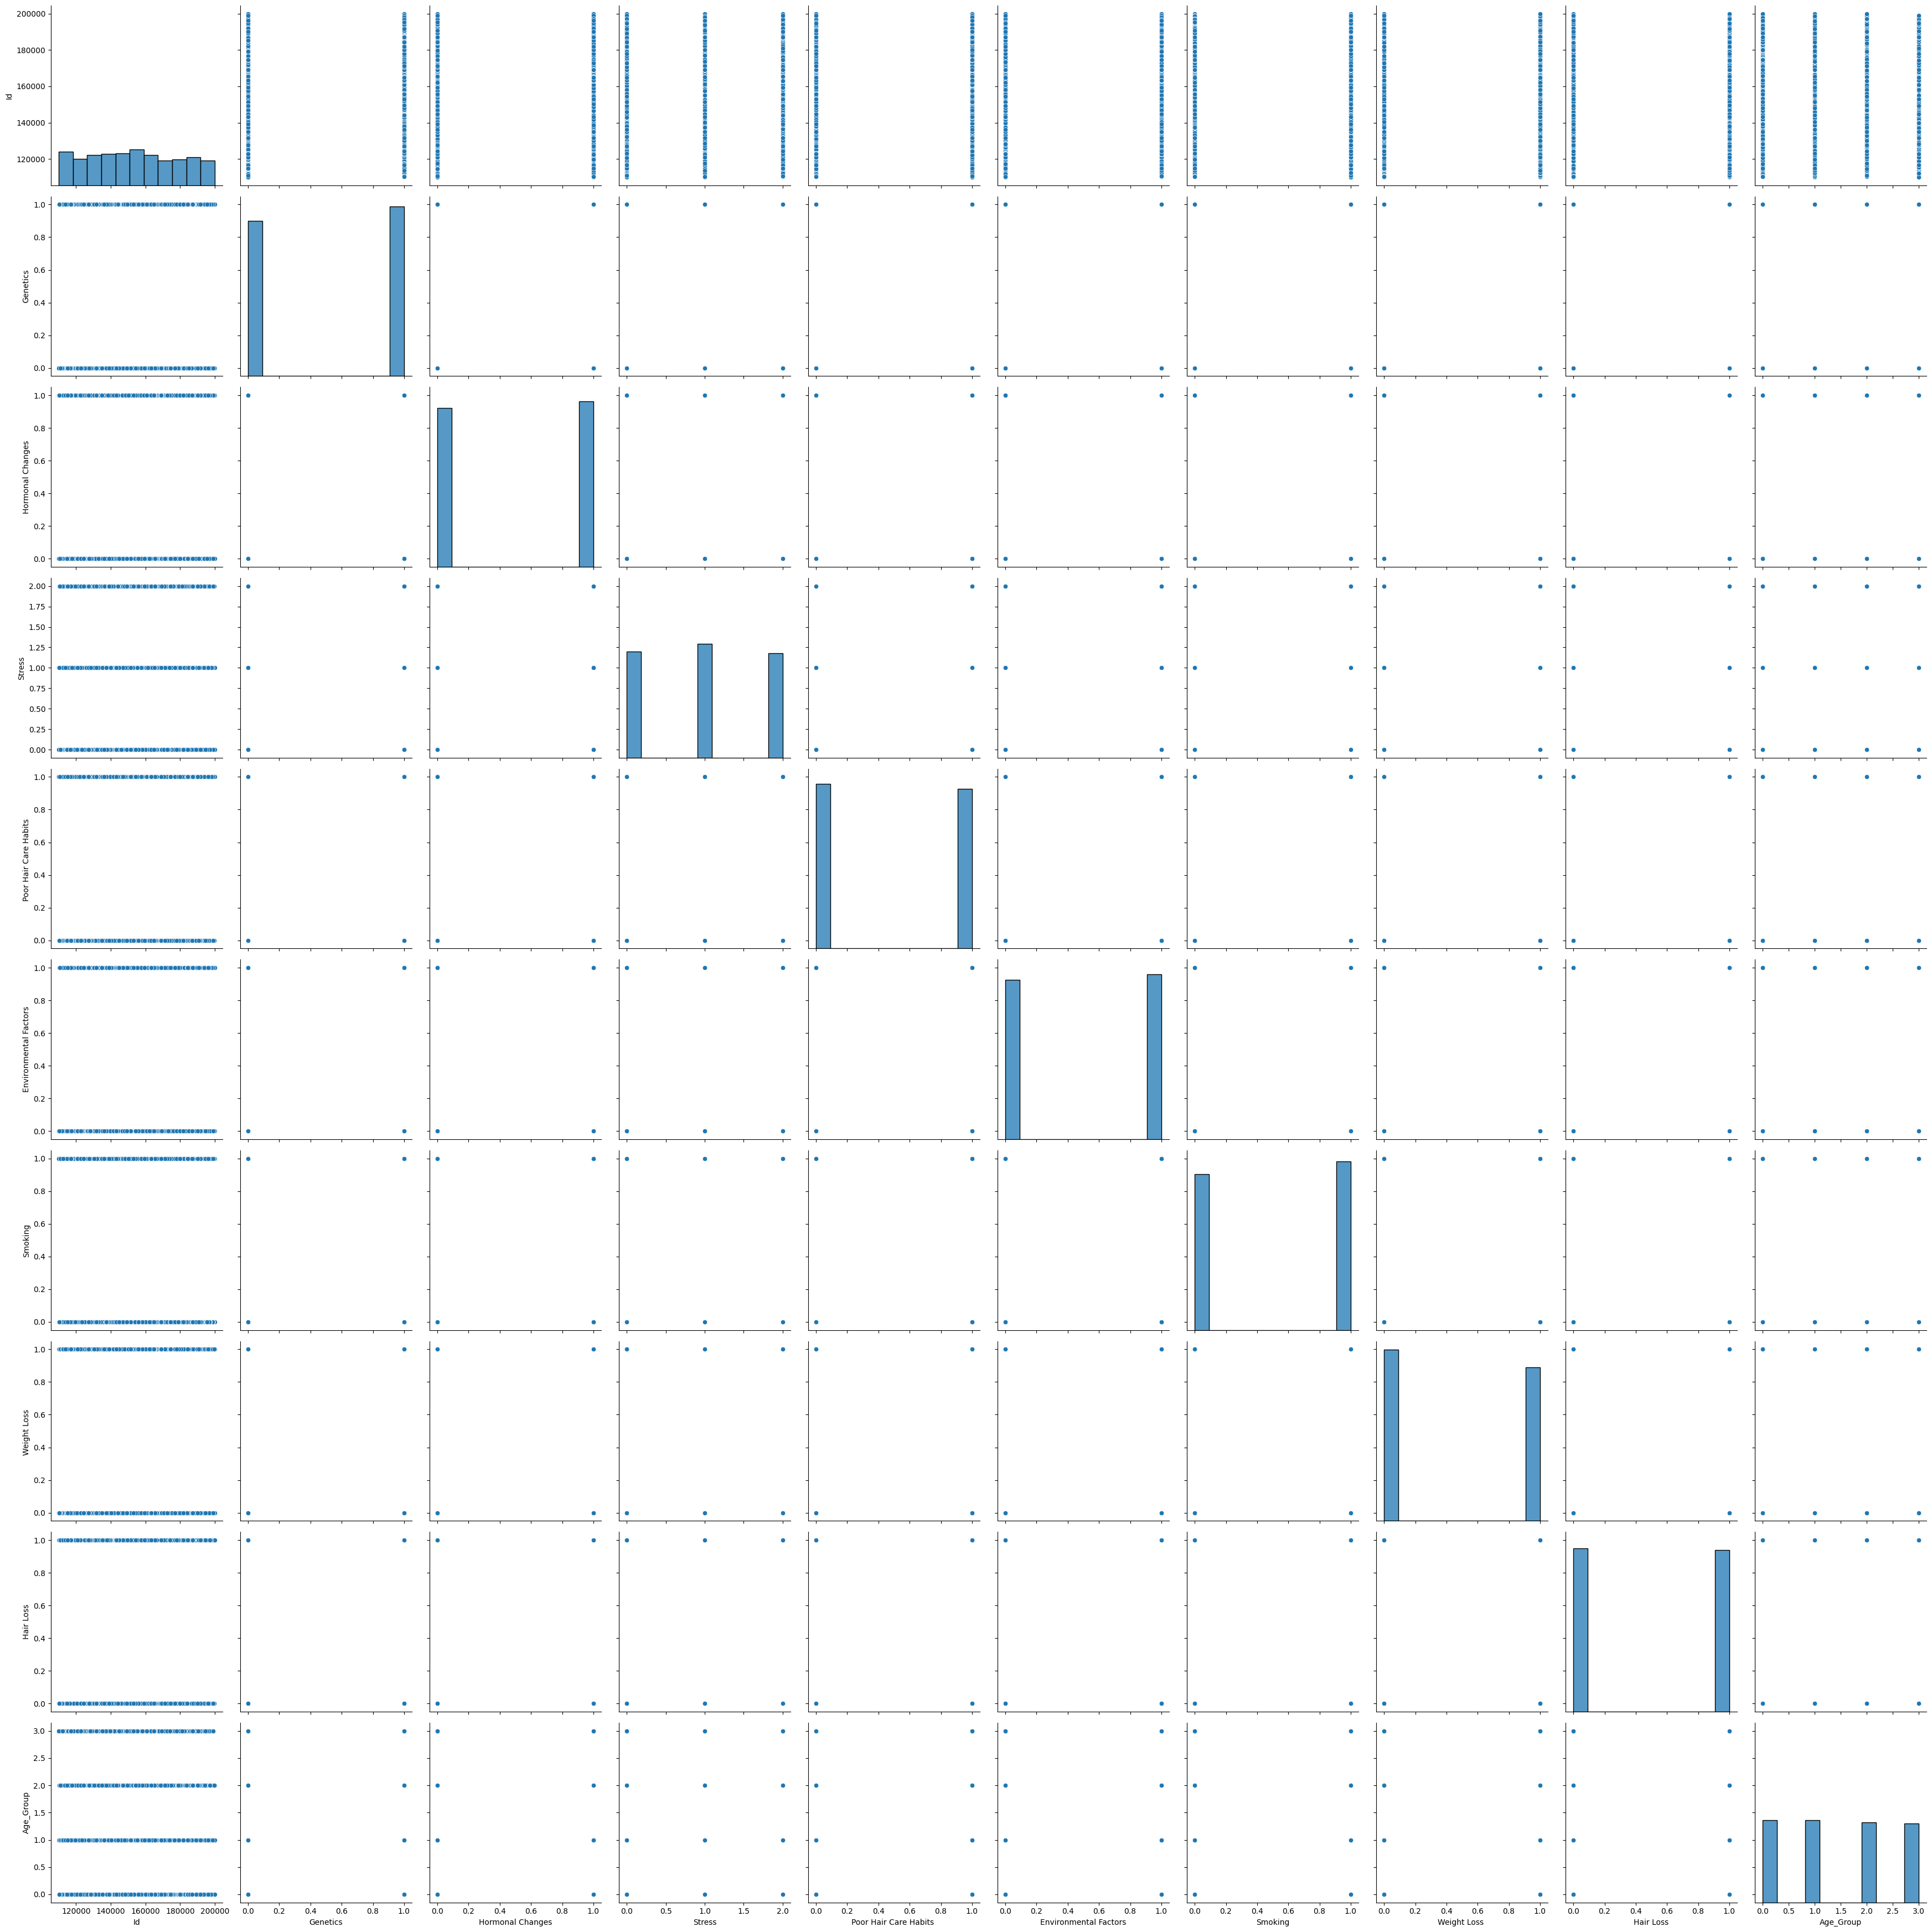

In [9]:
sns.pairplot(df, height=3.5)
plt.tight_layout()
plt.show()


Displaying the heatmap plot... Close the plot window to continue.


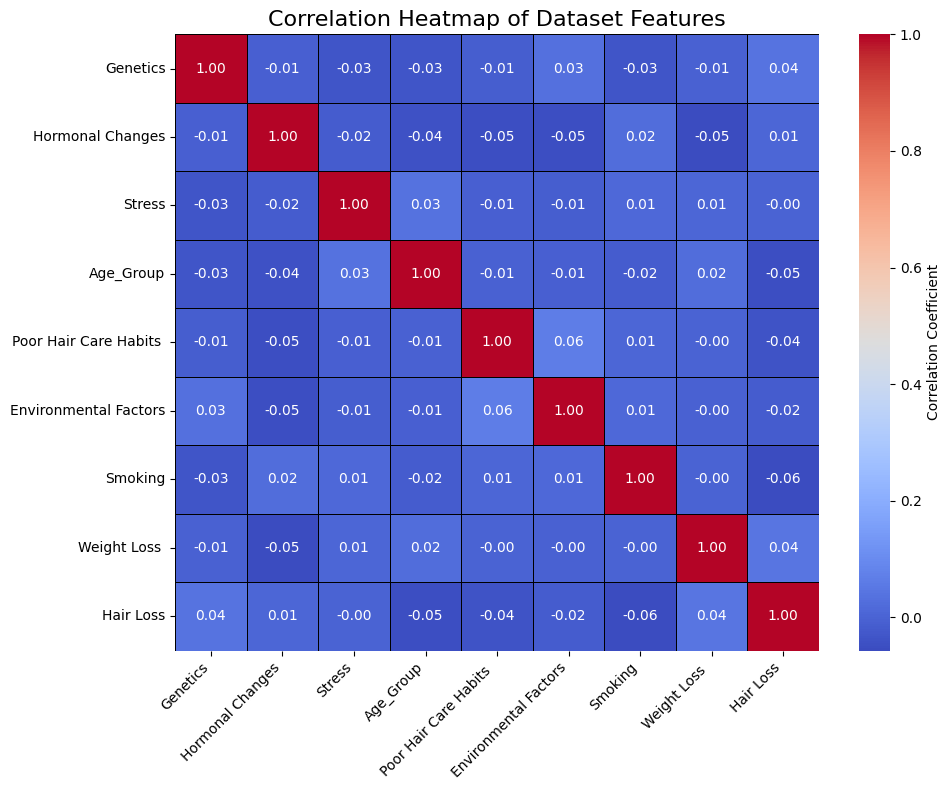

In [10]:
selected_features_for_heatmap = ['Genetics', 'Hormonal Changes', 'Stress', 'Age_Group', 'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking', 'Weight Loss ', 'Hair Loss']
correlation_matrix = df[selected_features_for_heatmap].corr()

plt.figure(figsize=(10, 8))

heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap of Dataset Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
print("\nDisplaying the heatmap plot... Close the plot window to continue.")
plt.show()



In [11]:
#One-hot encode Medical Conditions, Medications & TreatMents, Nutritional Deficiencies
df = pd.get_dummies(df, columns=['Medical Conditions', 'Medications & Treatments','Nutritional Deficiencies '])
df = df.astype(np.float32)

In [12]:
# Define features and target
features = [item for item in list(df.columns) if item not in ['Id','Hair Loss','Age']]
#features =  ['Genetics', 'Hormonal Changes', 'Weight Loss ', 'Stress']

#Check dataset before splitting
print(features)
df.head()

['Genetics', 'Hormonal Changes', 'Stress', 'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking', 'Weight Loss ', 'Age_Group', 'Medical Conditions_Alopecia Areata ', 'Medical Conditions_Androgenetic Alopecia', 'Medical Conditions_Dermatitis', 'Medical Conditions_Dermatosis', 'Medical Conditions_Eczema', 'Medical Conditions_MISSING', 'Medical Conditions_Psoriasis', 'Medical Conditions_Ringworm', 'Medical Conditions_Scalp Infection', 'Medical Conditions_Seborrheic Dermatitis', 'Medical Conditions_Thyroid Problems', 'Medications & Treatments_Accutane', 'Medications & Treatments_Antibiotics', 'Medications & Treatments_Antidepressants ', 'Medications & Treatments_Antifungal Cream', 'Medications & Treatments_Blood Pressure Medication', 'Medications & Treatments_Chemotherapy', 'Medications & Treatments_Heart Medication ', 'Medications & Treatments_Immunomodulators', 'Medications & Treatments_MISSING', 'Medications & Treatments_Rogaine', 'Medications & Treatments_Steroids', 'Nutritional

,Id,Genetics,Hormonal Changes,Stress,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss,Age_Group,...,Nutritional Deficiencies _Iron deficiency,Nutritional Deficiencies _MISSING,Nutritional Deficiencies _Magnesium deficiency,Nutritional Deficiencies _Omega-3 fatty acids,Nutritional Deficiencies _Protein deficiency,Nutritional Deficiencies _Selenium deficiency,Nutritional Deficiencies _Vitamin A Deficiency,Nutritional Deficiencies _Vitamin D Deficiency,Nutritional Deficiencies _Vitamin E deficiency,Nutritional Deficiencies _Zinc Deficiency
0,133992.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,148393.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,155074.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,118261.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,111915.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# # import pandas as pd
# # from sklearn.model_selection import train_test_split
# # from sklearn.preprocessing import StandardScaler
# # import numpy as np
# # import matplotlib.pyplot as plt
# # import seaborn as sns

# TARGET_COLUMN = 'Hair Loss'
# FILE_PATH = './dataset/Predict Hair Fall.csv' 

# try:
#     df = pd.read_csv(FILE_PATH)
#     print(f"Successfully loaded data from: {FILE_PATH}")
#     print(f"Initial shape: {df.shape}")
# except FileNotFoundError:
#     print(f"Error: File not found at '{FILE_PATH}'. Please ensure your file path is correct.")
#     exit()

# # Drop the non-predictive Id column
# df = df.drop('Id', axis=1, errors='ignore') 

# # --- 1. Encoding and Feature Engineering ---

# binary_cols = [
#     'Genetics', 
#     'Hormonal Changes', 
#     'Poor Hair Care Habits ',
#     'Environmental Factors', 
#     'Smoking', 
#     'Weight Loss '
# ]

# for col in binary_cols:
#     if col in df.columns:
#         df[col] = df[col].map({'Yes': 1, 'No': 0})
#         df[col] = df[col].fillna(0).astype(int) 

# # One-Hot Encoding
# stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
# if 'Stress' in df.columns:
#     df['Stress'] = df['Stress'].map(stress_mapping)
#     df['Stress'] = df['Stress'].fillna(1).astype(int)

# multi_value_cols = ['Medical Conditions', 'Nutritional Deficiencies ', 'Medications & Treatments'] 

# for col in multi_value_cols:
#     if col in df.columns:
#         df[col] = df[col].astype(str).str.replace(r'[\[\]\"]', '', regex=True).fillna('')
#         clean_col_name = col.strip().split(" ")[0].capitalize()
#         new_count_col = f'Num_{clean_col_name}_Count'
        
#         df[new_count_col] = df[col].apply(
#             lambda x: len([item.strip() for item in x.split(',') if item.strip() != ''])
#         )
        
#         df = df.drop(col, axis=1)

# if 'Age' in df.columns and 'Genetics' in df.columns and 'Poor Hair Care Habits ' in df.columns and 'Smoking' in df.columns:
    
#     df['Age_x_Genetics'] = df['Age'] * df['Genetics']
#     df['Smoking_x_PoorHairCare'] = df['Smoking'] * df['Poor Hair Care Habits ']


# numerical_cols = ['Age', 'Num_Medical_Count', 'Num_Nutritional_Count', 'Num_Medications_Count', 'Age_x_Genetics'] 
# scaler = StandardScaler()

# for col in numerical_cols:
#     if col in df.columns:
#         df[col] = df[col].fillna(df[col].mean())
#         # Apply scaling
#         df[[col]] = scaler.fit_transform(df[[col]])


# columns_to_drop_final = [
#     # 'Stress', 
#     # 'Hormonal Changes', 
#     # 'Environmental Factors', 
#     'Poor Hair Care Habits ',
#     'Smoking',
#     'Age'
# ]

# print(f"\n--- Feature Removal: Dropping {len(columns_to_drop_final)} weak features (r < 0.03) ---")
# df = df.drop(columns=columns_to_drop_final, errors='ignore')

# # Data Split

# if TARGET_COLUMN not in df.columns:
#     print(f"\nERROR: Target column '{TARGET_COLUMN}' not found. Please check the name.")
#     exit()

# X = df.drop(TARGET_COLUMN, axis=1)
# y = df[TARGET_COLUMN]

# # Split the data into Training and Testing sets (80% train, 20% test)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, 
#     test_size=0.2, 
#     random_state=42, 
#     stratify=y 
# )

# print("\n--- Preprocessing Complete ---")
# print(f"Shape of X_train (Features for Training): {X_train.shape}")
# print("\nFirst 5 rows of the NEW training data (X_train):")
# print(X_train.head())
# print("\nVerify that all remaining columns are numerical (0, 1, or scaled floats):")
# print(X_train.dtypes)

In [14]:
features = [item for item in list(df.columns) if item not in ['Id','Hair Loss','Age']]
X = df[features]
y = df['Hair Loss']

# First split: separate test set (10% of data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

In [15]:
#install necessary libraries
#pytorch
import torch
import torch.nn as nn
import torch.optim as optim

#helper libraries
from torch.utils.data import DataLoader
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score,
roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.model_selection import learning_curve

%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [16]:
print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (899, 41) (899,)
Test set shape: (100, 41) (100,)


In [17]:
from sklearn.neural_network import MLPClassifier

oneLayerModels = {
    'One Layer-16 NN': MLPClassifier(hidden_layer_sizes=(16), max_iter=15000, random_state=42),
    'One Layer-32 NN': MLPClassifier(hidden_layer_sizes=(32), max_iter=15000, random_state=42),
    'One Layer-64 NN': MLPClassifier(hidden_layer_sizes=(64), max_iter=15000, random_state=42),
    'One Layer-128 NN': MLPClassifier(hidden_layer_sizes=(128), max_iter=15000, random_state=42)
}

twoLayerModels = {
    'Two Layer-32-16 NN': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=15000, random_state=42),
    'Two Layer-64-32 NN': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=15000, random_state=42),
    'Two Layer-64-16 NN': MLPClassifier(hidden_layer_sizes=(64, 16), max_iter=15000, random_state=42),
}

threeLayerModels = {
    'Three Layer-64-32-16 NN': MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=15000, random_state=42),
    'Three Layer-128-64-32 NN': MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=15000, random_state=42),
    'Three Layer-256-128-64 NN': MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=15000, random_state=42),
    'Three Layer-64-64-64 NN': MLPClassifier(hidden_layer_sizes=(64, 64, 64), max_iter=15000, random_state=42),

}

fiveLayerModels = {
    '5 layer-64-32-16-8-4 NN': MLPClassifier(hidden_layer_sizes=(64, 32, 16, 8, 4), max_iter=15000, random_state=42),
    '5 layer-128-64-32-16-8 NN': MLPClassifier(hidden_layer_sizes=(128, 64, 32, 16, 8), max_iter=15000, random_state=42),
    '5 layer-256-128-64-32-16 NN': MLPClassifier(hidden_layer_sizes=(256, 128, 64, 32, 16), max_iter=15000, random_state=42),    
    '5 layer 64-64-64-64-64 NN': MLPClassifier(hidden_layer_sizes=(64, 64, 64, 64, 64), max_iter=15000, random_state=42)
}

models = oneLayerModels.copy()
models.update(twoLayerModels)
models.update(threeLayerModels)
models.update(fiveLayerModels)

modelVariations = [oneLayerModels, twoLayerModels, threeLayerModels, fiveLayerModels]

for name, model in models.items():
    model.fit(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    auc = roc_auc_score(y_test, model.predict(X_test))
    f1 = f1_score(y_test, model.predict(X_test))
    print(f'{name} Test Accuracy: {test_acc:.4f}, AUC: {auc:.4f}, F1 Score: {f1:.4f}')

One Layer-16 NN Test Accuracy: 0.5700, AUC: 0.5700, F1 Score: 0.6261
One Layer-32 NN Test Accuracy: 0.5500, AUC: 0.5500, F1 Score: 0.5714
One Layer-64 NN Test Accuracy: 0.5000, AUC: 0.5000, F1 Score: 0.5000
One Layer-128 NN Test Accuracy: 0.4900, AUC: 0.4900, F1 Score: 0.5143
Two Layer-32-16 NN Test Accuracy: 0.5300, AUC: 0.5300, F1 Score: 0.5607
Two Layer-64-32 NN Test Accuracy: 0.4900, AUC: 0.4900, F1 Score: 0.5487
Two Layer-64-16 NN Test Accuracy: 0.5000, AUC: 0.5000, F1 Score: 0.5370
Three Layer-64-32-16 NN Test Accuracy: 0.4500, AUC: 0.4500, F1 Score: 0.4860
Three Layer-128-64-32 NN Test Accuracy: 0.5100, AUC: 0.5100, F1 Score: 0.5333
Three Layer-256-128-64 NN Test Accuracy: 0.5100, AUC: 0.5100, F1 Score: 0.5586
Three Layer-64-64-64 NN Test Accuracy: 0.4800, AUC: 0.4800, F1 Score: 0.5185
5 layer-64-32-16-8-4 NN Test Accuracy: 0.4200, AUC: 0.4200, F1 Score: 0.4423
5 layer-128-64-32-16-8 NN Test Accuracy: 0.5000, AUC: 0.5000, F1 Score: 0.5192
5 layer-256-128-64-32-16 NN Test Accurac

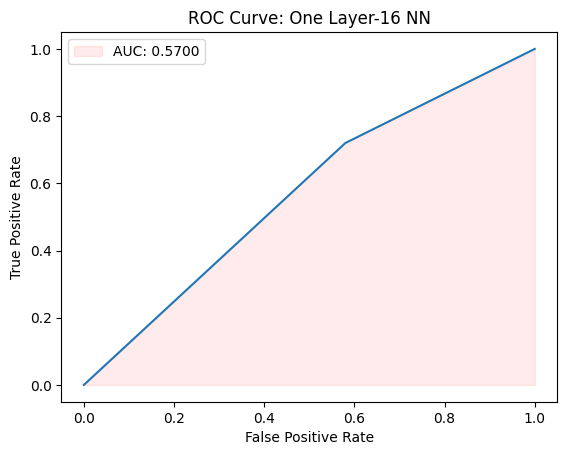

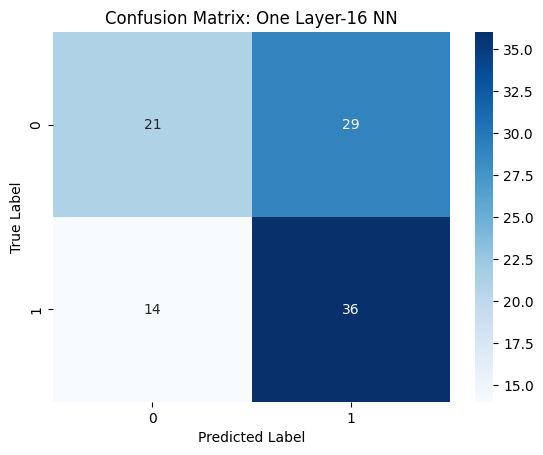

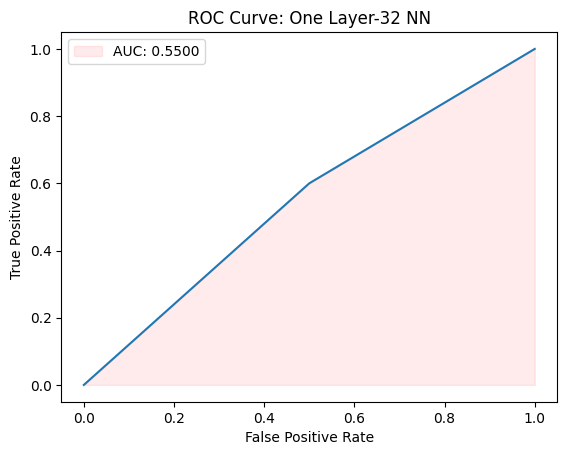

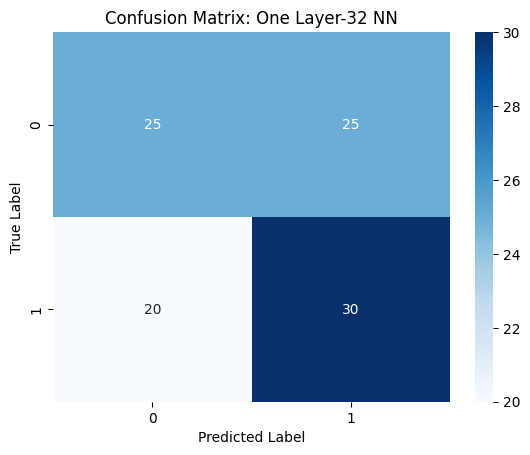

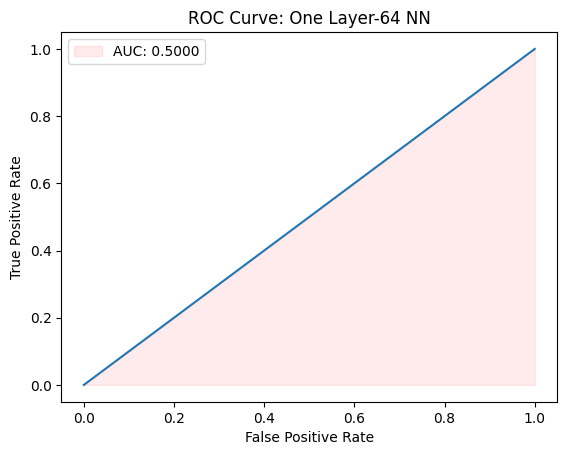

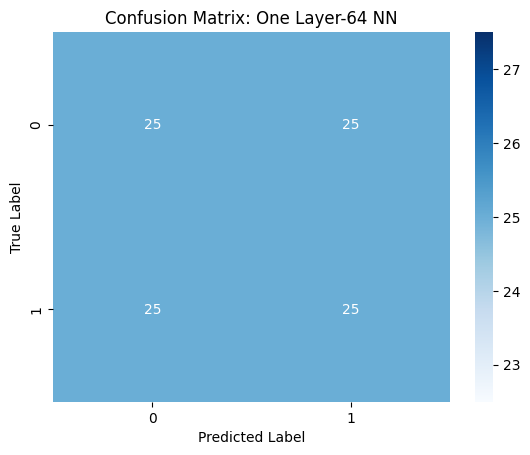

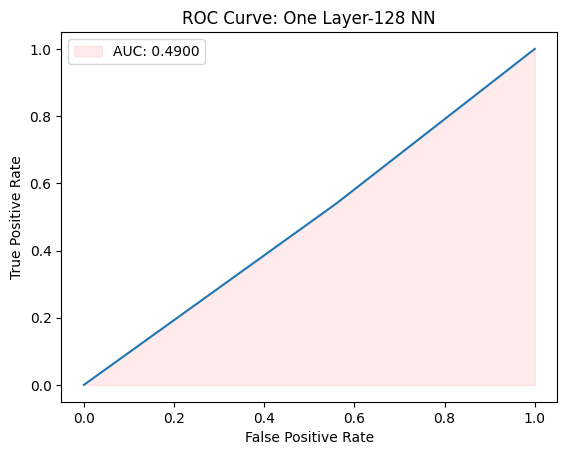

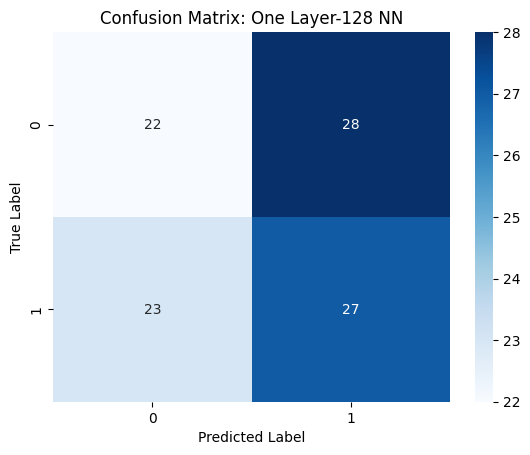

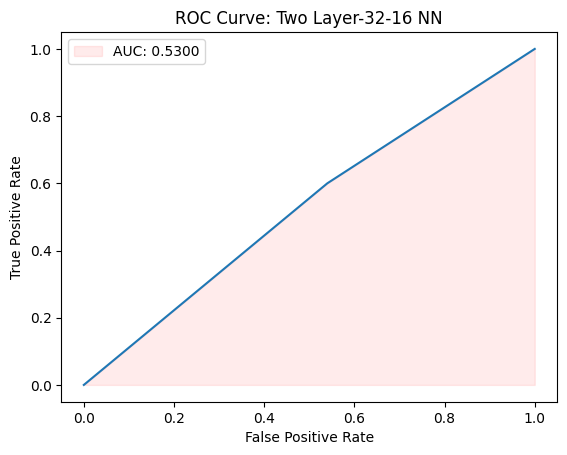

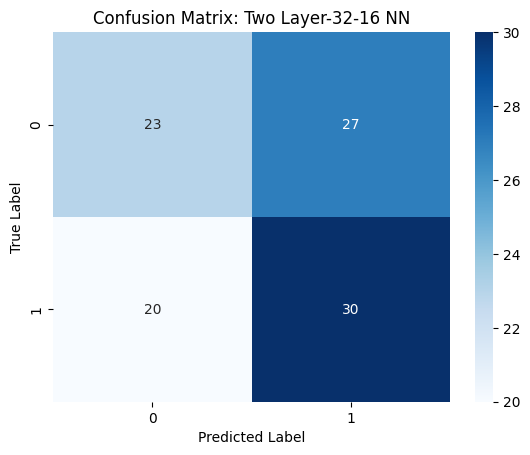

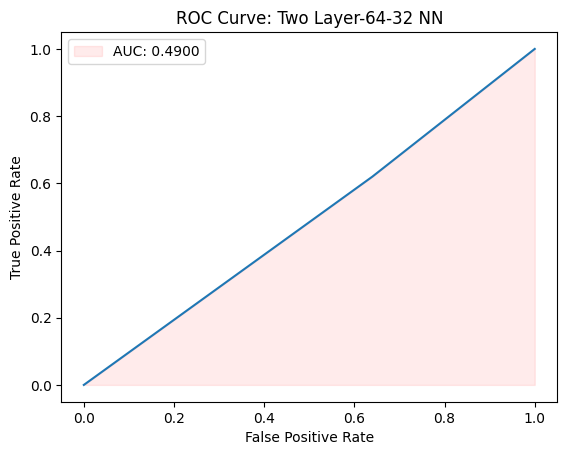

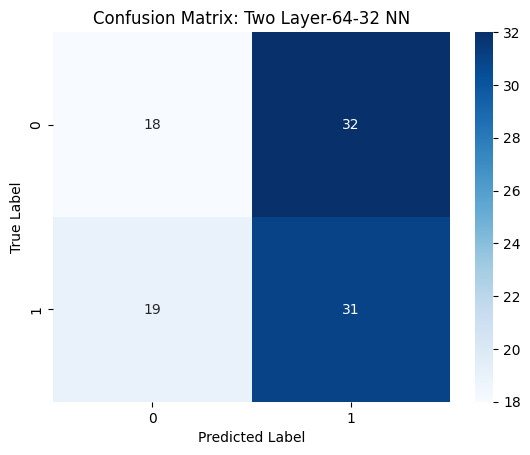

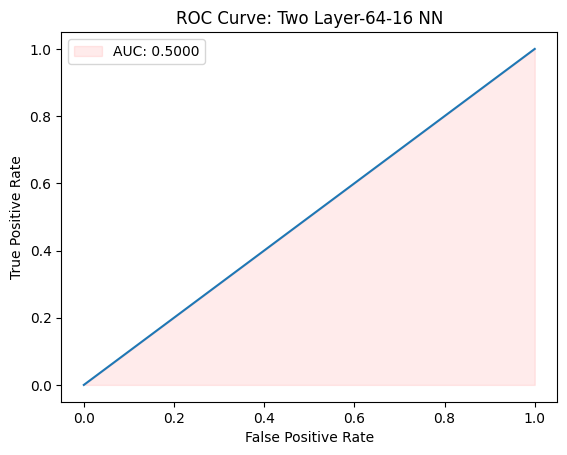

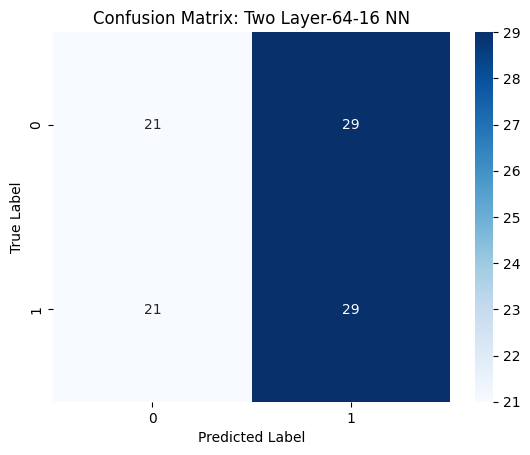

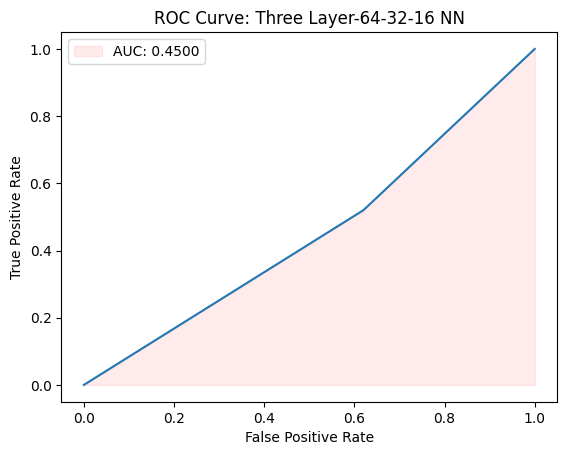

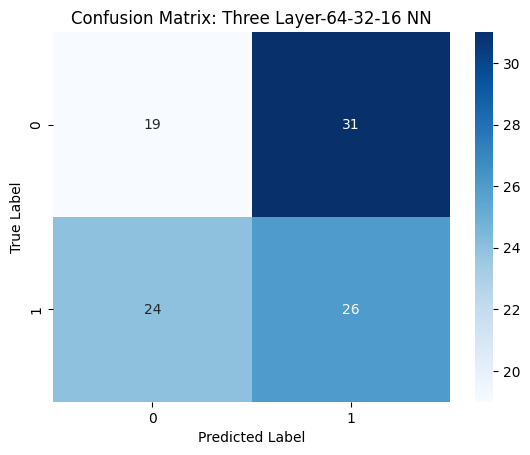

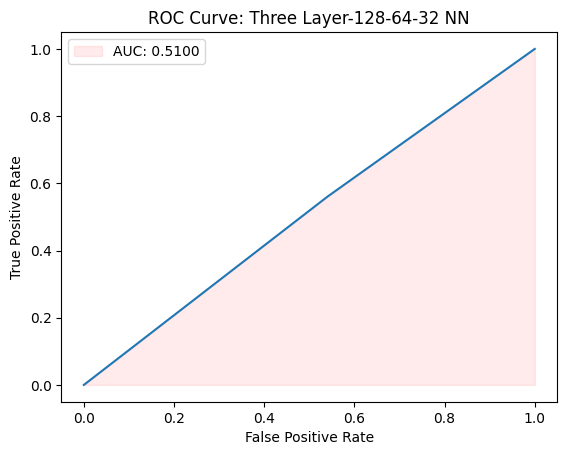

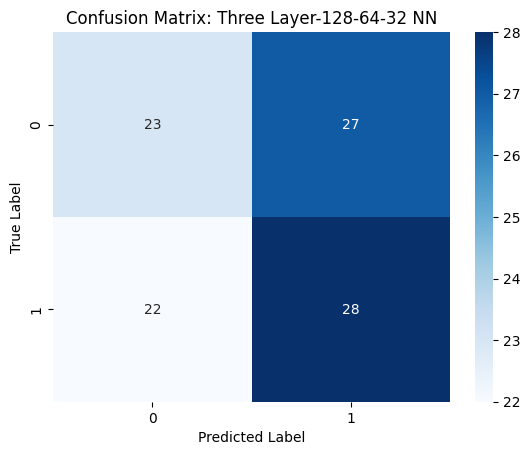

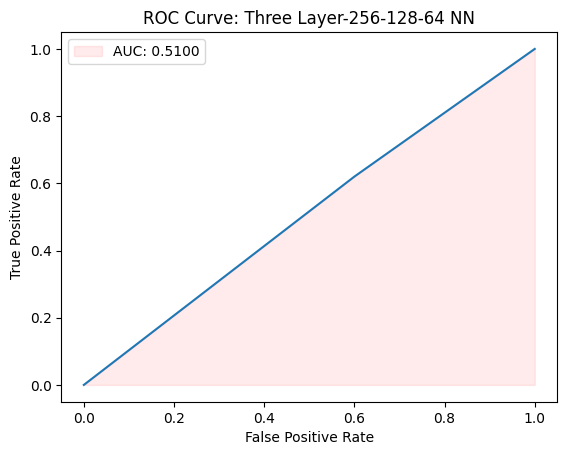

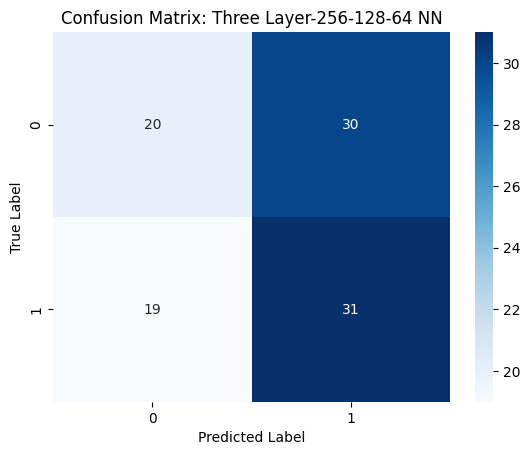

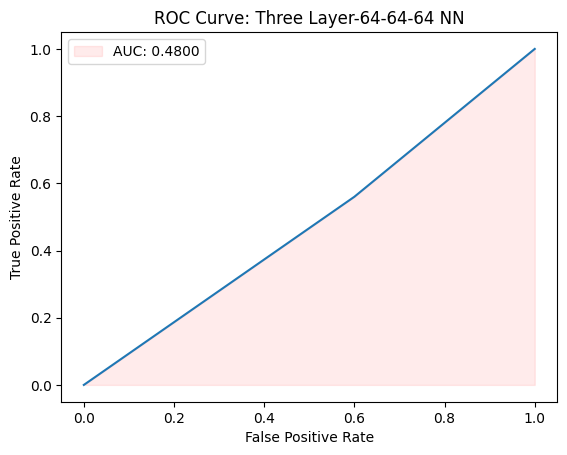

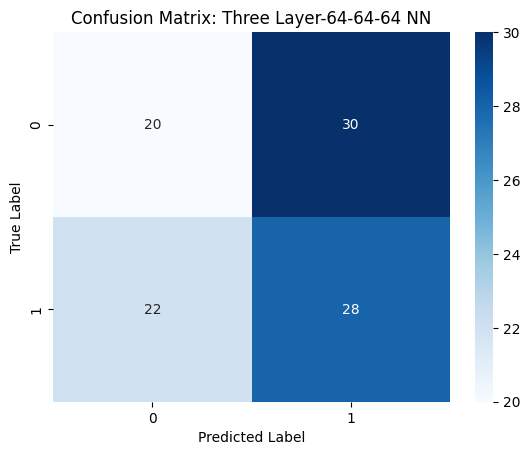

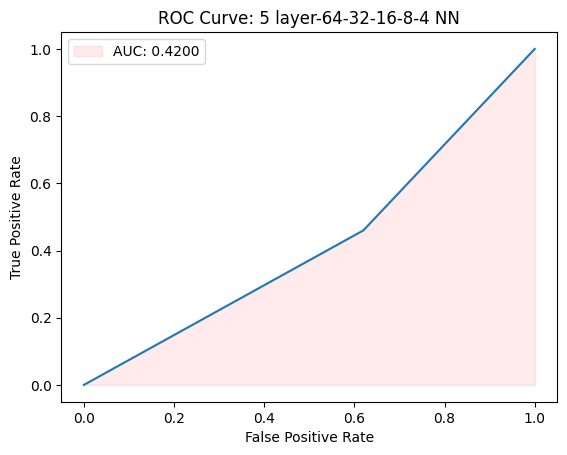

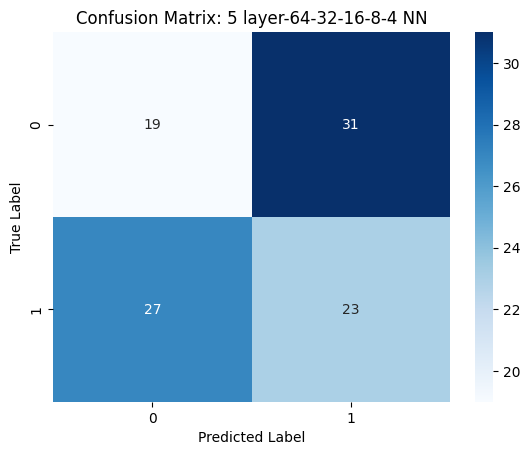

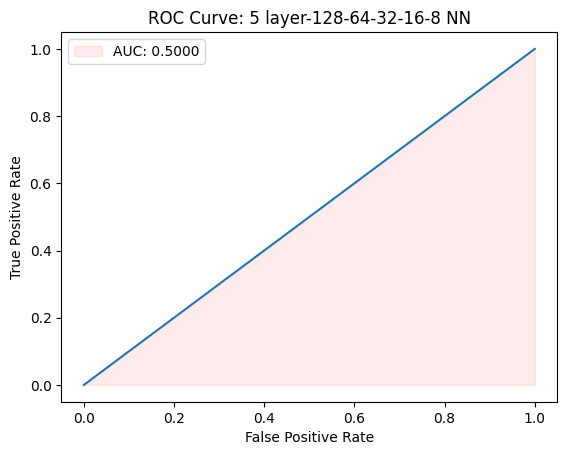

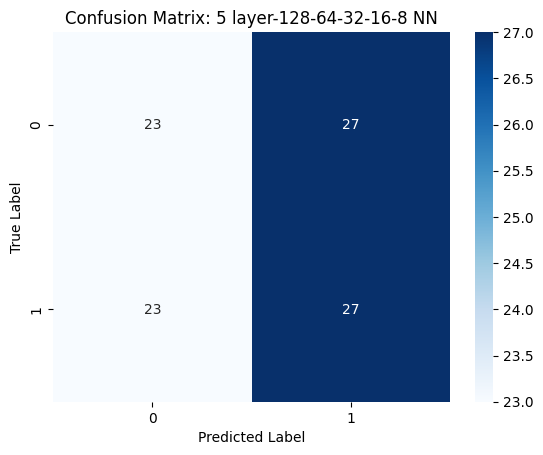

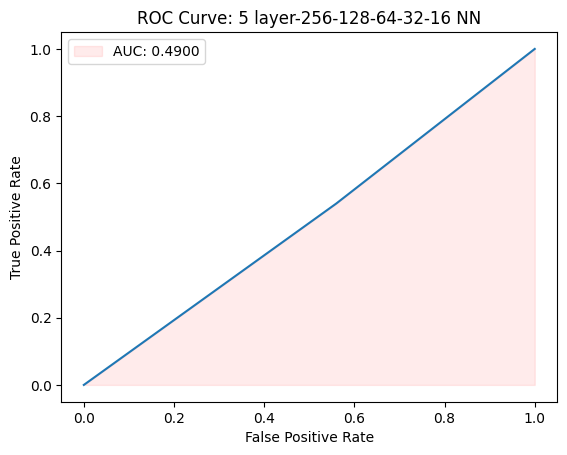

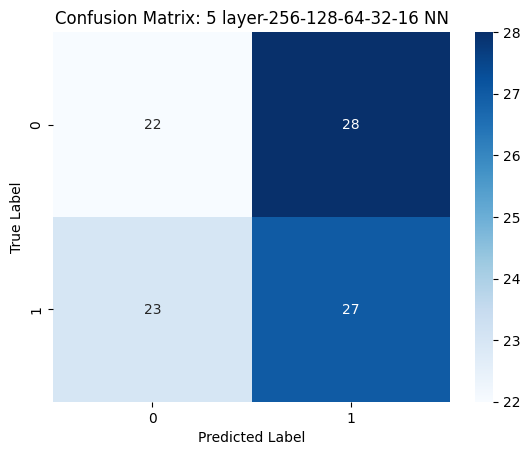

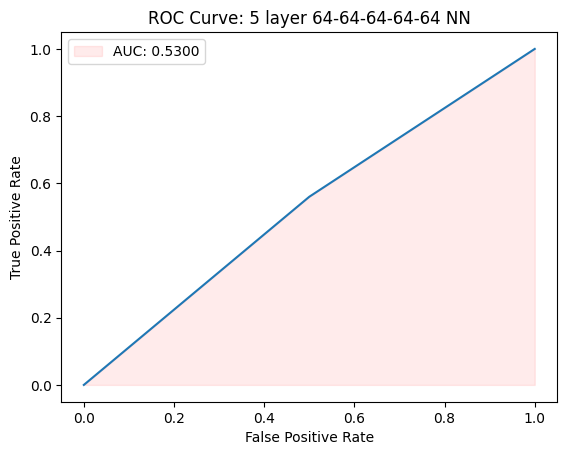

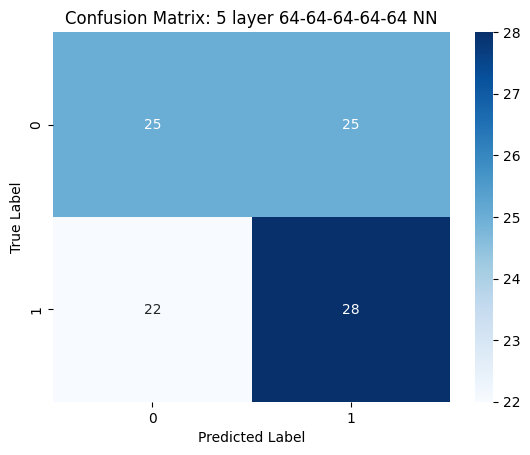

In [18]:
for name, model in models.items():
    fpr, tpr, thresholds = roc_curve(y_test, model.predict(X_test))
    auc = roc_auc_score(y_test, model.predict(X_test))
    auc =  "AUC: " + str(f"{auc:.4f}")
    plt.plot(fpr, tpr)
    plt.fill_between(fpr, tpr, color='red', alpha=0.08,label=auc)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve: ' + name)
    plt.legend()
    plt.show()

    cm = confusion_matrix(y_test, model.predict(X_test))
    ax = sns.heatmap(cm, fmt='d',annot=True, cmap='Blues')
    ax.set(xlabel ="Predicted Label", ylabel = 'True Label', title ='Confusion Matrix: ' + name)
    plt.show()

In [19]:
def drawLearningCurve(models, X, y):
    for ax, (name, model) in zip(axes, models.items()):
        train_sizes, train_scores, test_scores = learning_curve(
                model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
                train_sizes=np.linspace(0.1, 1.0, 10)
            )
        train_mean = np.mean(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        ax.plot(train_sizes, train_mean, 'o-', label='Training score')
        ax.plot(train_sizes, test_mean, 'o-', label='Cross-validation score')
        ax.axhline(y=0.94,c='r',ls='--')
        ax.set_title(name)
        ax.set_xlabel('Training examples')
        ax.set_ylabel('Accuracy')
        ax.grid(True)
    handles, labels = ax.get_legend_handles_labels()  # use last subplot to get handles
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=[0.5,-0.025], ncol=2, fontsize=12)
    fig.suptitle('Learning Curves: Variations of Neural Network Architectures', fontsize=14)
    plt.show()


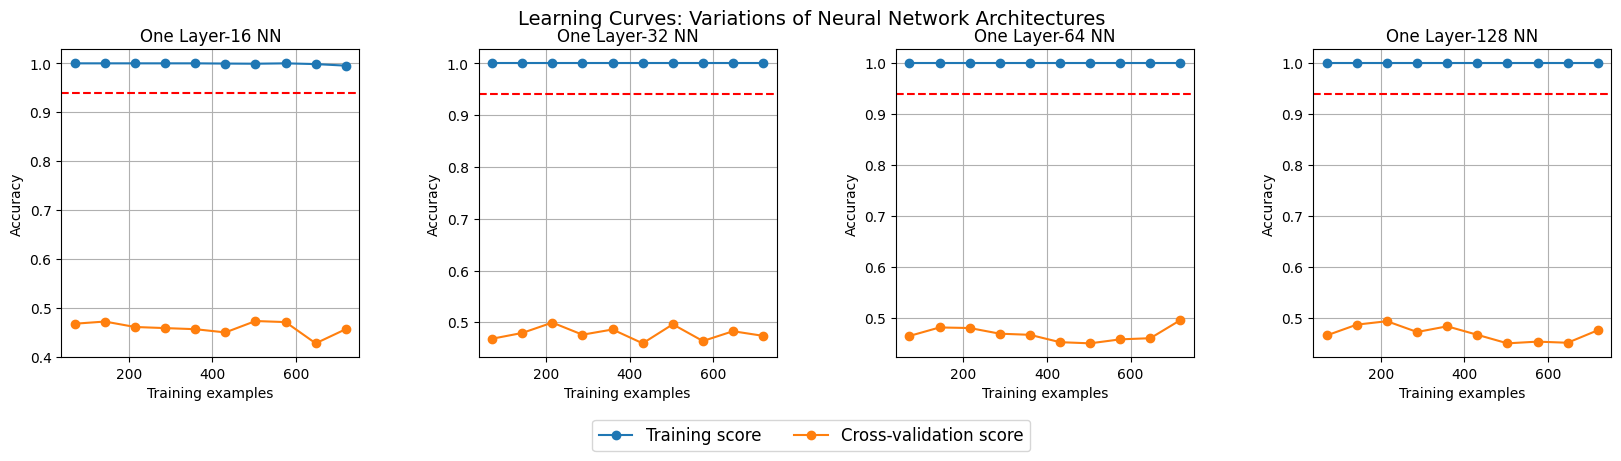

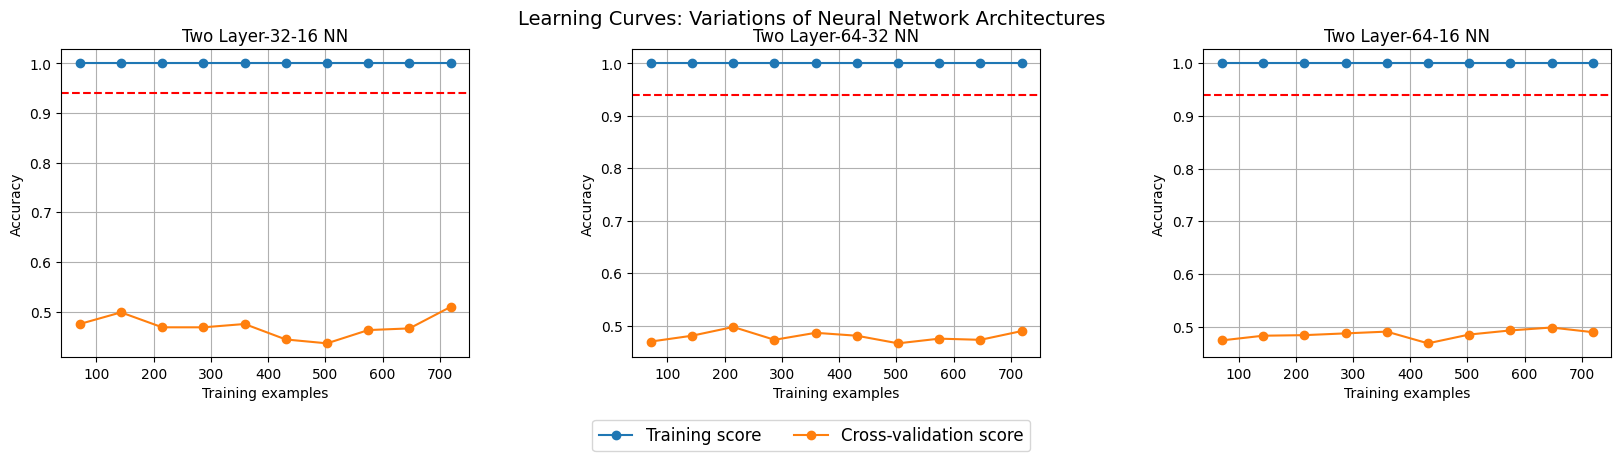

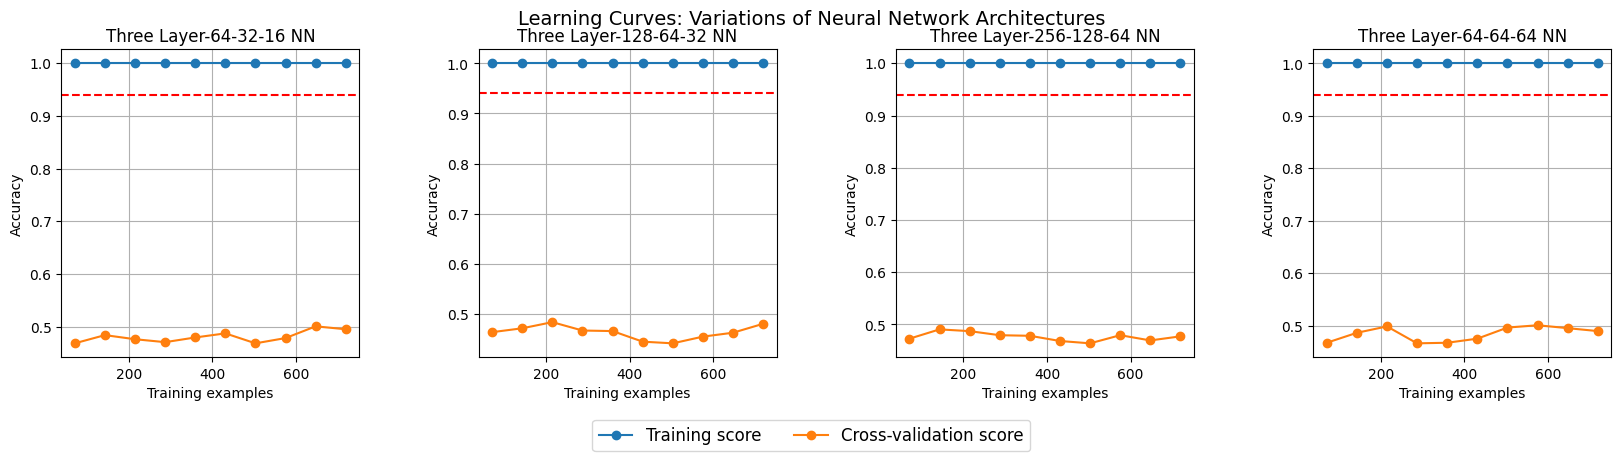

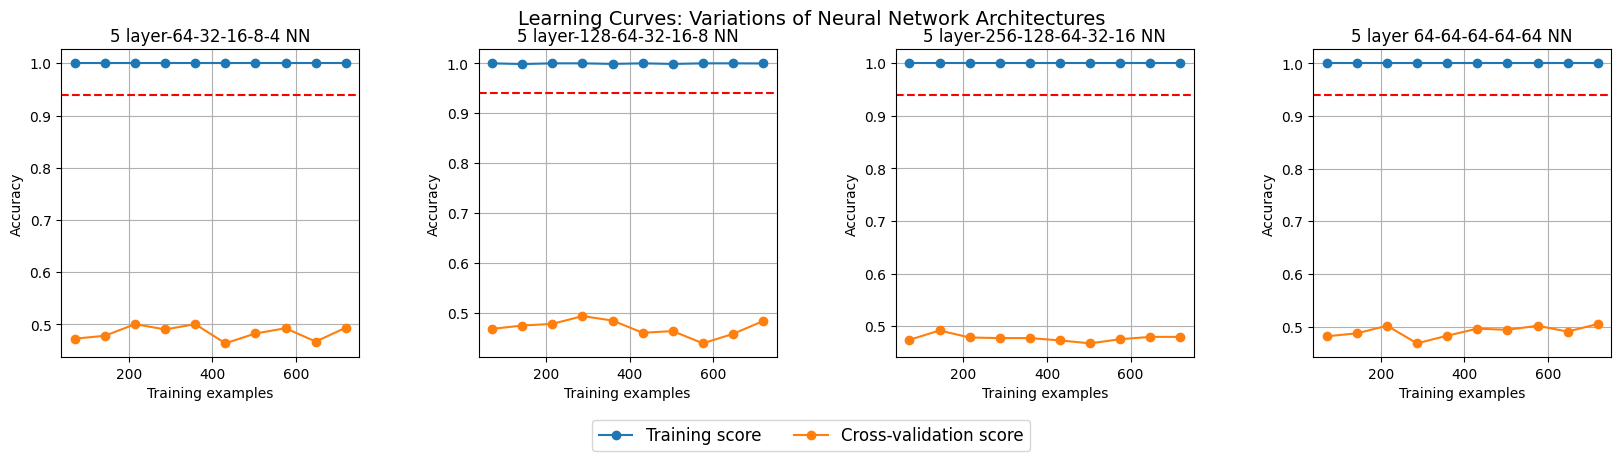

In [20]:
for modelVariation in modelVariations:
    fig, axes = plt.subplots(1, len(modelVariation), figsize=(20, 4))
    plt.subplots_adjust(wspace=0.4)
    drawLearningCurve(modelVariation, X_train, y_train)